In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

linear regression class
1. member variables
- parameter weights

2. main member functions
- fit: finds the dimension of the feature vector
- predict: computes y_predict based on weights
- train: computes weights of the model parameters
- normalize: normalizes data (could make a statistics library)

3. helper functions
- compute gradient
- gradient descent
- mean squared error

In [ ]:
penguins = pd.read_csv('../data/penguins.csv')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE


In [12]:
penguins_flipper_length = penguins['flipper_length_mm'].to_numpy()
penguins_flipper_length = penguins_flipper_length.reshape(342, 1)
penguins_body_mass = penguins['body_mass_g'].to_numpy()

X, y = penguins_flipper_length, penguins_body_mass

In [20]:
X_norm = (X - X.mean()) / X.std()
y_norm = (y - y.mean()) / y.std()

In [15]:
def gradient_descent(x, gf, step):
    dime = len(x)
    for i in range(dime):
        x[i] = x[i] - step*gf[i]
    return x

In [16]:
def mean_squared_error(errors):
    mse = 0
    for e in errors:
        mse += e**2
    return mse / len(errors)

In [17]:
def predict(weights, X):
    points = len(X)
    dimension = len(weights)
    y_pred = [weights[0] for _ in range(points)]

    for p in range(points):
        for d in range(1, dimension):
            y_pred[p] += weights[d] * X[p][d-1]
    
    return y_pred

In [27]:
def compute_gradient(errors, X):
    points = len(X)
    dimension = len(X[0]) + 1

    gradient = [0 for _ in range(dimension)]
    for p in range(points):
        gradient[0] += errors[p]
    gradient[0] = 2 * gradient[0] / points
    for d in range(1, dimension):
        for p in range(points):
            gradient[d] += errors[p]*X[p][d-1]
        gradient[d] = 2 * gradient[d] / points

    return gradient

In [28]:
def train(X, y, step=0.05, tol=1e-6, max_iter=1000):
    points = len(y)
    dimension = len(X[0]) + 1
    weights = [0 for _ in range(dimension)]

    for _ in range(max_iter):
        y_pred = predict(weights, X)
        errors = [y_pred[p] - y[p] for p in range(points)]

        if mean_squared_error(errors) < tol:
            return weights

        gradient = compute_gradient(errors, X)
        weights = gradient_descent(weights, gradient, step)

    return weights

In [29]:
train(X_norm, y_norm)

[np.float64(8.051389314839859e-16), np.float64(0.8712017673060107)]

In [31]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE


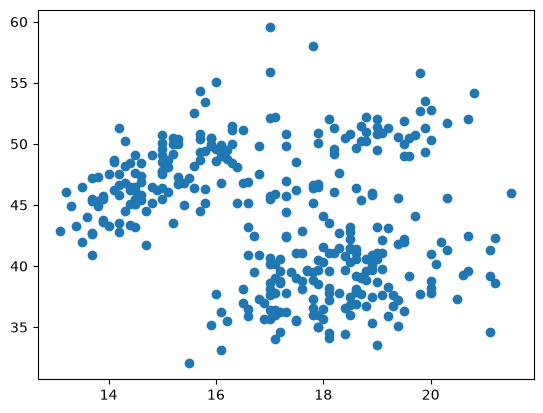

In [36]:
penguins_bill_length = penguins['bill_length_mm'].to_numpy()
penguins_bill_depth = penguins['bill_depth_mm'].to_numpy()
plt.scatter(penguins_bill_depth, penguins_bill_length)